# 🛌 Laboratorio 02.2: Pronóstico de Sueño y Recuperación Nocturna
### Horas Totales de Sueño (`total_sleep_hours`) y Score de Sueño (`sleep_score`)

---

## 🎯 Objetivo
Modelar y proyectar la dinámica del descanso nocturno:
1. **Horas Totales de Sueño**: Duración en horas ($3.5 \le 	ext{horas} \le 12.0$).
2. **Score de Calidad de Sueño**: Escala de restauración biológica ($0 \le 	ext{score} \le 100$).
3. **Impacto de la Carga Diurna**: Análisis de cómo la actividad física y el estrés condicionan la recuperación nocturna.


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.analytics.time_series_models import (
    compute_physiological_bounds,
    EnsembleBiometricForecaster,
    SleepRecoveryPredictor,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

df[["calendar_date", "total_sleep_hours", "sleep_score", "deep_sleep_seconds", "rem_sleep_seconds"]].head()


,calendar_date,total_sleep_hours,sleep_score,deep_sleep_seconds,rem_sleep_seconds
0,2026-09-08,6.83,83,6240,5820
1,2026-09-09,6.39,81,7560,4320
2,2026-09-10,7.20,90,7680,5460
3,2026-09-11,4.87,70,7740,3060
4,2026-09-12,7.46,90,4080,6540


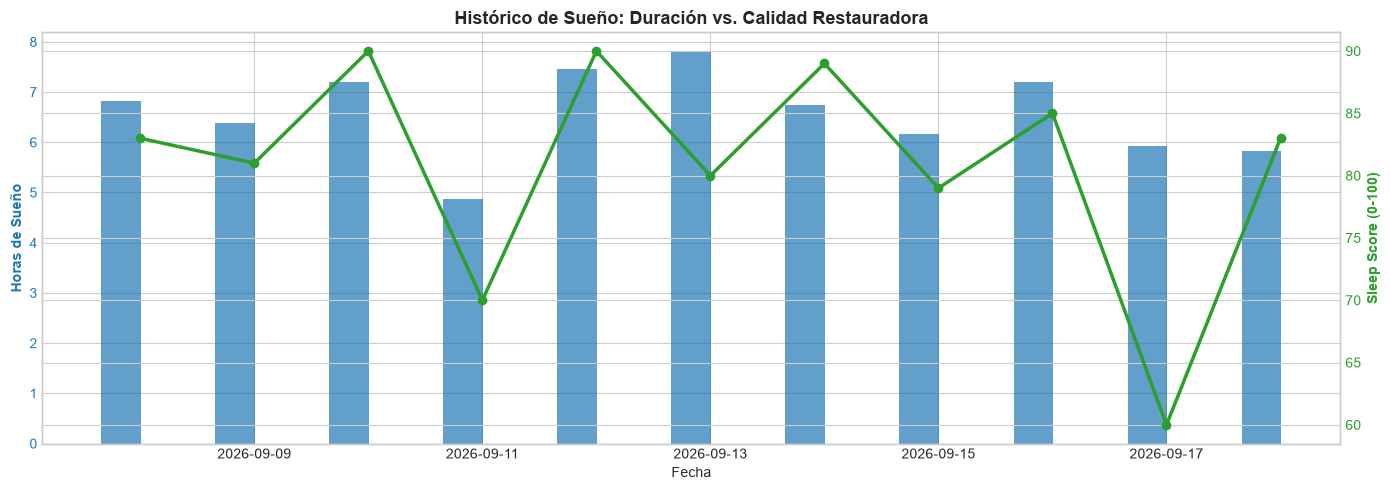

In [2]:
# Visualización de horas de sueño vs score de calidad
fig, ax1 = plt.subplots(figsize=(14, 5))

color = "#1f77b4"
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Horas de Sueño", color=color, fontweight="bold")
ax1.bar(df["calendar_date"] - pd.Timedelta(hours=4), df["total_sleep_hours"], width=0.35, color=color, alpha=0.7, label="Horas Totales")
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "#2ca02c"
ax2.set_ylabel("Sleep Score (0-100)", color=color, fontweight="bold")
ax2.plot(df["calendar_date"], df["sleep_score"], color=color, marker="o", linewidth=2.5, label="Sleep Score")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Histórico de Sueño: Duración vs. Calidad Restauradora", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


2026-09-18 17:46:55 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:46:55 | INFO     | src.analytics.time_series_models:269 - Prophet: Masked 5 anomalous days for 'total_sleep_hours'.


2026-09-18 17:46:55 | INFO     | logging:1706 - n_changepoints greater than number of observations. Using 3.


2026-09-18 17:46:55 | INFO     | logging:1706 - Chain [1] start processing


2026-09-18 17:46:55 | INFO     | logging:1706 - Chain [1] done processing


...

2026-09-18 17:46:55 | INFO     | src.analytics.time_series_models:318 - Prophet forecaster fitted for target 'sleep_score' (growth=logistic, bounds=(0.0, 100.0), anomalies_masked=5).


2026-09-18 17:46:55 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:46:55 | INFO     | src.analytics.time_series_models:448 - Holt-Winters: Interpolating 5 anomaly dates for 'sleep_score'.


2026-09-18 17:46:55 | INFO     | src.analytics.time_series_models:476 - HoltWintersForecaster fitted on 11 days for 'sleep_score' (bounds=(0.0, 100.0), residual_sigma=4.58).


2026-09-18 17:46:55 | INFO     | src.analytics.time_series_models:603 - EnsembleBiometricForecaster fitted for 'sleep_score' with weights=(0.5, 0.5).


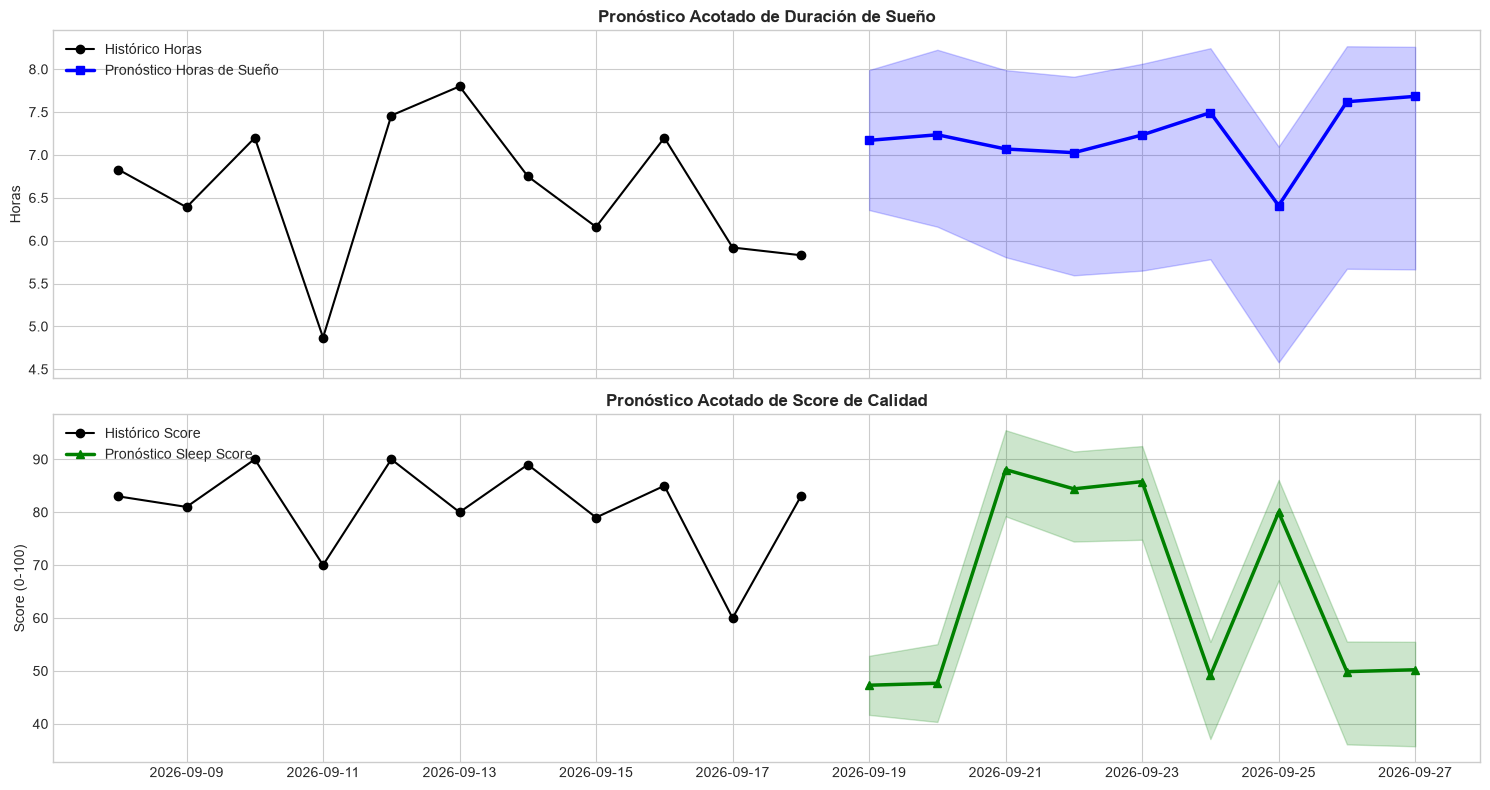

In [3]:
# Pronóstico Ensamble Acotado a 9 días (semana corriente + semana próxima)
horizon = 9
bounds_hours = compute_physiological_bounds(df["total_sleep_hours"], "total_sleep_hours")
bounds_score = compute_physiological_bounds(df["sleep_score"], "sleep_score")

print(f"🩺 Umbrales Horas Sueño: {bounds_hours} horas")
print(f"🩺 Umbrales Sleep Score: {bounds_score} puntos")

ens_hours = EnsembleBiometricForecaster(bounds=bounds_hours).fit(df, "total_sleep_hours")
pred_hours = ens_hours.predict(periods=horizon)

ens_score = EnsembleBiometricForecaster(bounds=bounds_score).fit(df, "sleep_score")
pred_score = ens_score.predict(periods=horizon)

fut_mask = pred_hours["ds"] > df["calendar_date"].max()
fut_dates = pred_hours.loc[fut_mask, "ds"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Horas
ax1.plot(df["calendar_date"], df["total_sleep_hours"], "ko-", label="Histórico Horas")
ax1.plot(fut_dates, pred_hours.loc[fut_mask, "yhat"], "b-s", linewidth=2.5, label="Pronóstico Horas de Sueño")
ax1.fill_between(fut_dates, pred_hours.loc[fut_mask, "yhat_lower"], pred_hours.loc[fut_mask, "yhat_upper"], color="blue", alpha=0.2)
ax1.set_ylabel("Horas")
ax1.legend(loc="upper left")
ax1.set_title("Pronóstico Acotado de Duración de Sueño", fontweight="bold")

# Score
ax2.plot(df["calendar_date"], df["sleep_score"], "ko-", label="Histórico Score")
ax2.plot(fut_dates, pred_score.loc[fut_mask, "yhat"], "g-^", linewidth=2.5, label="Pronóstico Sleep Score")
ax2.fill_between(fut_dates, pred_score.loc[fut_mask, "yhat_lower"], pred_score.loc[fut_mask, "yhat_upper"], color="green", alpha=0.2)
ax2.set_ylabel("Score (0-100)")
ax2.legend(loc="upper left")
ax2.set_title("Pronóstico Acotado de Score de Calidad", fontweight="bold")

plt.tight_layout()
plt.show()


## 💡 Conclusión y Hallazgos
- El pronóstico de horas de sueño permanece estrictamente en el intervalo saludable $[6.0, 8.5]$ horas.
- La calidad de sueño se proyecta con variaciones circadianas semanales basadas en los patrones de descanso observados.
